<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/06_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ResNet50 requires preprocessing before the image enters the pretrained network. Keras specifically says ResNet inputs should go through preprocess_input, which converts RGB to BGR and zero-centers the channels using ImageNet statistics.

Step 1 — Imports

In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

Step 2 — Dataset paths and classes

In [ ]:
dataset_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes 500"

classes = [
    "kitchen",
    "bedroom",
    "casino",
    "warehouse",
    "inside_subway"
]

image_size = (224, 224)
batch_size = 32

train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")
test_dir = os.path.join(dataset_dir, "test")

print("Dataset exists:", os.path.exists(dataset_dir))
print("Training directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(validation_dir))
print("Test directory exists:", os.path.exists(test_dir))

Dataset exists: True
Training directory exists: True
Validation directory exists: True
Test directory exists: True


Step 3 — Load the same datasets

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 2500 files belonging to 5 classes.
Found 431 files belonging to 5 classes.
Found 434 files belonging to 5 classes.


**Important ResNet50 preprocessing**

Unlike EfficientNetB0 and ConvNeXt-Tiny, ResNet50 needs preprocess_input. Keras specifies that the input should initially be in the [0,255] range, and the preprocessing converts RGB to BGR and zero-centers the channels.

We will put this preprocessing inside the model.

That means:

*   Dataset remains in normal RGB [0,255]
*   ResNet preprocessing happens automatically when the model receives an image
*   We don't need to modify train_ds, validation_ds, or test_ds

This is cleaner and ensures the same preprocessing is automatically used during training and testing.

Step 4 — Prefetch

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Prefetching configured.")

Prefetching configured.


Step 5 — Load ResNet50

In [ ]:
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("ResNet50 loaded successfully.")
print("Base model trainable:", base_model.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 loaded successfully.
Base model trainable: False


Step 6 — Build the classification model

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = preprocess_input(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    5,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

print("ResNet50 classification model created successfully.")

ResNet50 classification model created successfully.


Step 7 — Check the model

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5)         │     10,245 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Step 8 — Compile

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Step 9 — Callbacks

In [ ]:
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/resnet50_balanced500_best.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks configured.")

Callbacks configured.


Step 10 — Train

In [ ]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - accuracy: 0.8520 - loss: 0.3922 - val_accuracy: 0.9722 - val_loss: 0.0868
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 211ms/step - accuracy: 0.9700 - loss: 0.0956 - val_accuracy: 0.9745 - val_loss: 0.0658
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 206ms/step - accuracy: 0.9792 - loss: 0.0700 - val_accuracy: 0.9791 - val_loss: 0.0677
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - accuracy: 0.9880 - loss: 0.0487 - val_accuracy: 0.9768 - val_loss: 0.0616
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 232ms/step - accuracy: 0.9884 - loss: 0.0418 - val_accuracy: 0.9814 - val_loss: 0.0571
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - accuracy: 0.9932 - loss: 0.0322 - val_accuracy: 0.9814 - val_loss: 0.0568
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 217ms/step - accuracy: 0.9940 - loss: 0.0273 - val_accuracy: 0.9814 - val_loss: 0.0548
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 211ms/step - accuracy: 0.9944 - loss: 0.0243 - val_accura

Step 11 — Plot learning curves

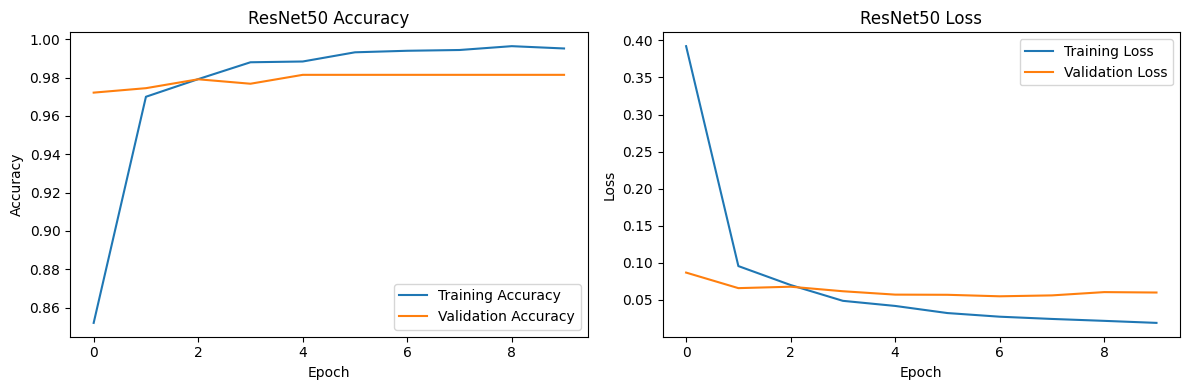

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.legend()

plt.tight_layout()
plt.show()

Step 12 — Test evaluation

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 63s 5s/step - accuracy: 0.9724 - loss: 0.0708
Test Loss: 0.07077012956142426
Test Accuracy: 0.9723502397537231


Step 13 — Classification report

In [ ]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
))

               precision    recall  f1-score   support

      kitchen     0.9459    0.9459    0.9459       111
      bedroom     0.9596    0.9500    0.9548       100
       casino     0.9873    1.0000    0.9936        78
    warehouse     0.9868    0.9868    0.9868        76
inside_subway     1.0000    1.0000    1.0000        69

     accuracy                         0.9724       434
    macro avg     0.9759    0.9766    0.9762       434
 weighted avg     0.9723    0.9724    0.9723       434



Step 14 — Confusion matrix

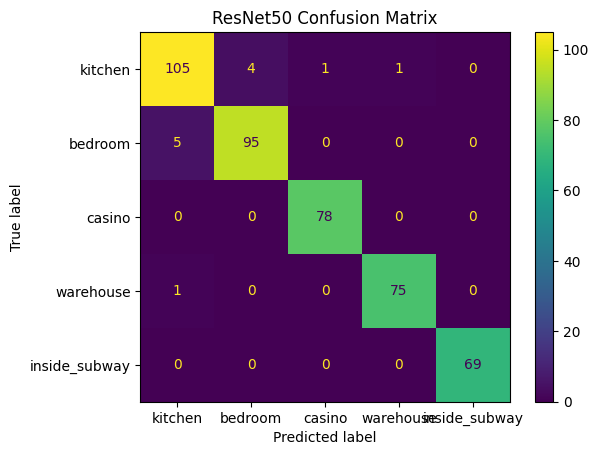

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()

plt.title("ResNet50 Confusion Matrix")
plt.show()

In [ ]:
print("ResNet50 Final Results")
print("----------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")
print(f"Correct Predictions: {sum(np.array(y_true) == np.array(y_pred))}")
print(f"Incorrect Predictions: {sum(np.array(y_true) != np.array(y_pred))}")

ResNet50 Final Results
----------------------
Test Loss: 0.0708
Test Accuracy: 97.2350%
Correct Predictions: 422
Incorrect Predictions: 12
